In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations

In [2]:
path = "../dataset/AzureFunctionsInvocationTraceForTwoWeeksJan2021.txt"
df = pd.read_csv(path)

In [3]:

# Compute derived columns
df['arrival_time'] = df['end_timestamp'] - df['duration']
df.sort_values(by='arrival_time', inplace=True)
hour_trace = 4
df['trace_id'] = (df['arrival_time'] // (hour_trace * 3600)).astype(int)
df['arrival_time_norm'] = df['arrival_time'] - (df['trace_id'] * hour_trace * 3600)

In [217]:
# Categories (min_req, max_req, num_func)
categories = [
    (50, 100, 2),    # Category 1
    (100, 150, 2),  # Category 2
    (160, 250, 3)   # Category 3
]

min_count = 2  # minimum gaps required
best_groups = []

for cat_idx, (min_req, max_req, num_func) in enumerate(categories):
    best_score = -1
    best_group = None

    for trace_id in df['trace_id'].unique():
        trace = df[df['trace_id'] == trace_id]
        func_counts = trace['func'].value_counts()
        candidate_funcs = func_counts[
            (func_counts >= min_req) & (func_counts <= max_req)
        ].index.tolist()
        
        if len(candidate_funcs) < num_func:
            continue

        for funcs in combinations(candidate_funcs, num_func):
            covs = []
            valid = True

            for f in funcs:
                times = trace[trace['func'] == f]['arrival_time_norm'].sort_values().values
                if len(times) < 2:
                    valid = False
                    break
                gaps = np.diff(times)
                if len(gaps) < min_count or np.mean(gaps) == 0:
                    valid = False
                    break
                cov = np.std(gaps) / np.mean(gaps)
                covs.append(cov)

            if not valid:
                continue

            avg_cov = np.mean(covs)

            # if cat_idx == 0:
            #     target_cov = 0.5
            #     closest_diff = float('inf')
            #     diff = abs(avg_cov - target_cov)
            #     if diff < closest_diff:
            #         closest_diff = diff
            #         best_group = {
            #             'category': cat_idx + 1,
            #             'trace_id': trace_id,
            #             'functions': list(funcs),
            #             'avg_cov': avg_cov
            #         }
            # else:
            if (avg_cov > best_score):
                best_score = avg_cov
                best_group = {
                    'category': cat_idx + 1,
                    'trace_id': trace_id,
                    'functions': list(funcs),
                    'avg_cov': avg_cov
                }
    # print("************************")

    if best_group:
        best_groups.append(best_group)
    

# Final result
result_df = pd.DataFrame(best_groups)
print(result_df)

   category  trace_id                                          functions  \
0         1        34  [32c6e2d6d752d3c30c43a9891766d887e0d25d3880344...   
1         2        77  [9b61fd55aa093a2d172db1a68a60af5cf6cbfa7f5ea1f...   
2         3        71  [1bfbf6e1f849d22a0ece669507eb055525edf6929f273...   

    avg_cov  
0  7.060458  
1  7.947572  
2  6.702835  


/tmp/ipykernel_910114/4029340866.py:45: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


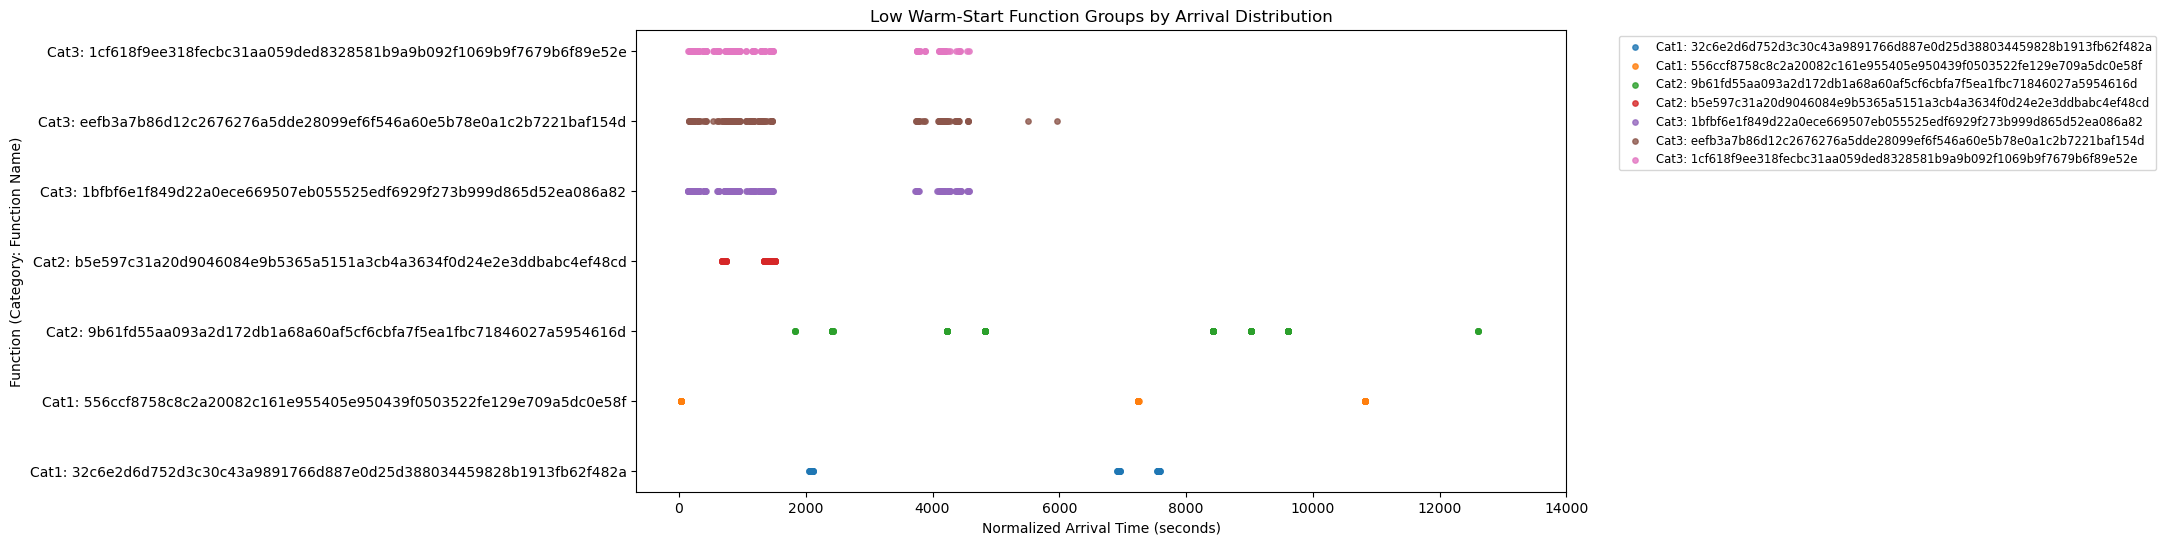

In [218]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 6))

all_funcs = []
all_func_colors = {}
colors = plt.cm.tab10.colors
color_idx = 0

for _, entry in result_df.iterrows():
    trace_id = entry['trace_id']
    cat = entry['category']
    # if cat != 3:
    #     continue
    funcs = entry['functions']
    cat_color = colors[cat % len(colors)]
    for func in funcs:
        func_label = f"Cat{cat}: {func}"
        all_funcs.append(func_label)
        all_func_colors[func_label] = colors[color_idx % len(colors)]
        color_idx += 1
        func_df = df[(df['trace_id'] == trace_id) & (df['func'] == func)]
        plt.scatter(
            func_df['arrival_time_norm'],
            [func_label] * len(func_df),
            s=15,
            color=all_func_colors[func_label],
            label=func_label,
            alpha=0.8
        )


# Optional: Set max x-axis range
plt.xlim(right=14000)

# Deduplicate legend entries
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

plt.xlabel("Normalized Arrival Time (seconds)")
plt.ylabel("Function (Category: Function Name)")
plt.title("Low Warm-Start Function Groups by Arrival Distribution")
plt.tight_layout()
plt.show()


In [219]:
data = ['alexnet', 'efficientnet', 'bert', 'distilgpt2', 'resnet50', 'googlenet', 'inception']
i = 0 
res = []
name_header = ['func','trace_id','category_id','id','memory','file_path']
for l in best_groups:
    total_subset = len(l['functions'])
    
    for k in range(0,total_subset):
        temp = []
        trace_id = l['trace_id']
        category_id = l['category']
        func = data[i]
        memory = 1024
        file_path = data[i]+".py"
        id_val = l['functions'][k]
        i += 1
        res.append([func, trace_id, category_id, id_val, memory, file_path])

res_df = pd.DataFrame(res,columns=name_header)
func_dict = res_df.set_index('id')['func'].to_dict()
func_dict

{'32c6e2d6d752d3c30c43a9891766d887e0d25d388034459828b1913fb62f482a': 'alexnet',
 '556ccf8758c8c2a20082c161e955405e950439f0503522fe129e709a5dc0e58f': 'efficientnet',
 '9b61fd55aa093a2d172db1a68a60af5cf6cbfa7f5ea1fbc71846027a5954616d': 'bert',
 'b5e597c31a20d9046084e9b5365a5151a3cb4a3634f0d24e2e3ddbabc4ef48cd': 'distilgpt2',
 '1bfbf6e1f849d22a0ece669507eb055525edf6929f273b999d865d52ea086a82': 'resnet50',
 'eefb3a7b86d12c2676276a5dde28099ef6f546a60e5b78e0a1c2b7221baf154d': 'googlenet',
 '1cf618f9ee318fecbc31aa059ded8328581b9a9b092f1069b9f7679b6f89e52e': 'inception'}

In [220]:
best_df_list = []

for _, entry in result_df.iterrows():
    trace_id = entry['trace_id']
    funcs = entry['functions']
    filtered = df[(df['trace_id'] == trace_id) & (df['func'].isin(funcs))]
    best_df_list.append(filtered)

# Concatenate all the filtered DataFrames
best_df = pd.concat(best_df_list, ignore_index=True)

# Optional: Sort by trace_id and arrival_time_norm for convenience
best_df = best_df.sort_values(by=['trace_id', 'func', 'arrival_time_norm']).reset_index(drop=True)

# Corrected normalization of arrival_time (if needed again)
best_df['arrival_time'] = best_df['arrival_time_norm']




In [221]:
best_df['func_id'] = best_df['func'].map(func_dict)
best_df

,app,func,end_timestamp,duration,arrival_time,trace_id,arrival_time_norm,func_id
0,4dd59aea96ab30b4156e2166b472206ff912315495a3c4...,32c6e2d6d752d3c30c43a9891766d887e0d25d38803445...,4.916640e+05,8.900,2055.132612,34,2055.132612,alexnet
1,4dd59aea96ab30b4156e2166b472206ff912315495a3c4...,32c6e2d6d752d3c30c43a9891766d887e0d25d38803445...,4.916642e+05,7.862,2056.383502,34,2056.383502,alexnet
2,4dd59aea96ab30b4156e2166b472206ff912315495a3c4...,32c6e2d6d752d3c30c43a9891766d887e0d25d38803445...,4.916687e+05,4.577,2064.088131,34,2064.088131,alexnet
3,4dd59aea96ab30b4156e2166b472206ff912315495a3c4...,32c6e2d6d752d3c30c43a9891766d887e0d25d38803445...,4.916686e+05,4.316,2064.262121,34,2064.262121,alexnet
4,4dd59aea96ab30b4156e2166b472206ff912315495a3c4...,32c6e2d6d752d3c30c43a9891766d887e0d25d38803445...,4.916798e+05,13.135,2066.657001,34,2066.657001,alexnet
...,...,...,...,...,...,...,...,...
991,b5450811f2226912d7c86164eeca69e414c0407a871525...,b5e597c31a20d9046084e9b5365a5151a3cb4a3634f0d2...,1.110316e+06,3.477,1512.197309,77,1512.197309,distilgpt2
992,b5450811f2226912d7c86164eeca69e414c0407a871525...,b5e597c31a20d9046084e9b5365a5151a3cb4a3634f0d2...,1.110319e+06,3.458,1515.895325,77,1515.895325,distilgpt2
993,b5450811f2226912d7c86164eeca69e414c0407a871525...,b5e597c31a20d9046084e9b5365a5151a3cb4a3634f0d2...,1.110320e+06,3.402,1516.255347,77,1516.255347,distilgpt2
994,b5450811f2226912d7c86164eeca69e414c0407a871525...,b5e597c31a20d9046084e9b5365a5151a3cb4a3634f0d2...,1.110320e+06,3.429,1516.256242,77,1516.256242,distilgpt2


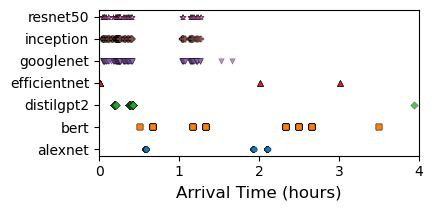

In [234]:
import matplotlib.pyplot as plt
import itertools

# Convert seconds to hours for x-axis
best_df['arrival_time_hr'] = best_df['arrival_time'] / 3600.0

# Marker styles to cycle through
markers = itertools.cycle(('o', 's', 'D', '^', 'v', 'P', '*'))

plt.figure(figsize=(4.5, 2.2))

# Plot each function group with style
for func_id, group in best_df.groupby('func_id'):
    plt.scatter(
        group['arrival_time_hr'],
        [func_id]*len(group),
        s=15,
        alpha=0.75,
        marker=next(markers),
        edgecolors='k',
        linewidths=0.2
    )

plt.xlabel("Arrival Time (hours)", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlim(0, 4)
# plt.grid(True, linestyle='--', linewidth=0.4)
plt.tight_layout()
plt.savefig("graphs_images/bursty_dataset_graph.png", dpi=300, bbox_inches='tight')
plt.show()


In [223]:
category_counts = best_df['func_id'].value_counts().sort_index()
category_counts

func_id
alexnet          91
bert            131
distilgpt2      128
efficientnet     65
googlenet       195
inception       168
resnet50        218
Name: count, dtype: int64

In [231]:
best_df = best_df.sort_values(by='arrival_time', ascending=True)

res_df.to_csv('../dataset/bursty_gen_functions.csv', index=False)
best_df.to_csv('../dataset/bursty_gen_df.csv', index=False)

In [233]:
best_df

,app,func,end_timestamp,duration,arrival_time,trace_id,arrival_time_norm,func_id,arrival_time_hr
91,734272c01926d19690e5ec308bab64ef97950b75b1c758...,556ccf8758c8c2a20082c161e955405e950439f0503522...,4.897970e+05,163.844,33.146984,34,33.146984,efficientnet,0.009207
92,734272c01926d19690e5ec308bab64ef97950b75b1c758...,556ccf8758c8c2a20082c161e955405e950439f0503522...,4.897457e+05,112.418,33.258446,34,33.258446,efficientnet,0.009238
93,734272c01926d19690e5ec308bab64ef97950b75b1c758...,556ccf8758c8c2a20082c161e955405e950439f0503522...,4.897012e+05,67.958,33.263472,34,33.263472,efficientnet,0.009240
94,734272c01926d19690e5ec308bab64ef97950b75b1c758...,556ccf8758c8c2a20082c161e955405e950439f0503522...,4.897525e+05,119.262,33.264645,34,33.264645,efficientnet,0.009240
95,734272c01926d19690e5ec308bab64ef97950b75b1c758...,556ccf8758c8c2a20082c161e955405e950439f0503522...,4.897511e+05,117.801,33.264759,34,33.264759,efficientnet,0.009240
...,...,...,...,...,...,...,...,...,...
864,734272c01926d19690e5ec308bab64ef97950b75b1c758...,9b61fd55aa093a2d172db1a68a60af5cf6cbfa7f5ea1fb...,1.121410e+06,3.951,12606.037128,77,12606.037128,bert,3.501677
865,734272c01926d19690e5ec308bab64ef97950b75b1c758...,9b61fd55aa093a2d172db1a68a60af5cf6cbfa7f5ea1fb...,1.121410e+06,3.921,12606.037813,77,12606.037813,bert,3.501677
866,734272c01926d19690e5ec308bab64ef97950b75b1c758...,9b61fd55aa093a2d172db1a68a60af5cf6cbfa7f5ea1fb...,1.121410e+06,3.925,12606.038110,77,12606.038110,bert,3.501677
867,734272c01926d19690e5ec308bab64ef97950b75b1c758...,9b61fd55aa093a2d172db1a68a60af5cf6cbfa7f5ea1fb...,1.121410e+06,3.790,12606.039599,77,12606.039599,bert,3.501678
